# Classifying LIGO Detector Glitches with a Convolutional Neural Network

**Gravity Spy dataset — 22 glitch classes | 92.4% test accuracy**

Gravitational-wave detectors like LIGO are sensitive enough to measure a change in length
a fraction of the width of a proton. That sensitivity means they also pick up an enormous
amount of instrumental and environmental noise. These transient noise artifacts are called
**glitches**, and they can mimic or mask real astrophysical signals.

The Gravity Spy project sorts glitches into 22 morphological classes so that detector
scientists can trace each family back to its physical cause. This notebook trains a
convolutional neural network to perform that classification directly from spectrogram images.

**Contents**
1. Setup and data loading
2. Exploring the 22 glitch classes
3. Preprocessing pipeline
4. CNN architecture
5. Training
6. Evaluation and error analysis

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 1. Data

The dataset is split into three directories on disk, one subfolder per glitch class:

| Split | Images |
|---|---|
| Train | 22,348 |
| Validation | 4,800 |
| Test | 4,720 |

The test set is held out entirely and used only once, at the end.

In [3]:
train_dir = './archive/train/train/'
test_dir = './archive/test/test/'
validation_dir = './archive/validation/validation/'

In [4]:
class_names = os.listdir(train_dir)
class_names.remove('.DS_Store')

## 2. What the 22 classes look like

Each image is a time–frequency spectrogram: time on the horizontal axis, frequency on the
vertical, brightness showing signal power. The classes are named after their visual
morphology — `Blip`, `Koi_Fish`, `Scattered_Light`, `Whistle`, and so on. Plotting one
example per class shows why this is a vision problem: the classes are genuinely
distinguishable by shape and texture.

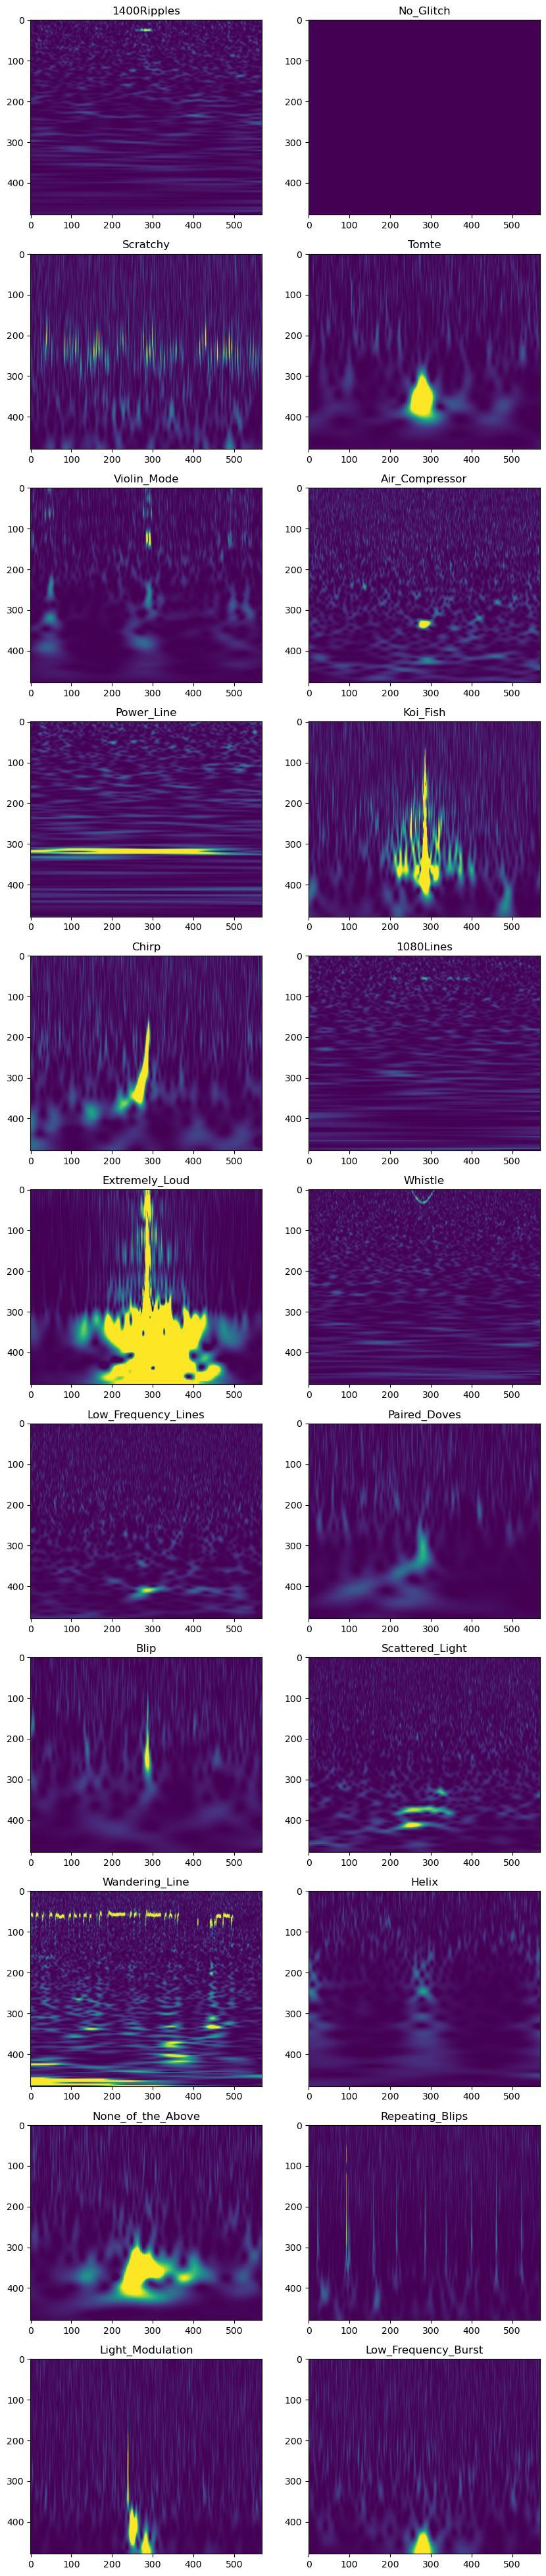

In [5]:
plt.figure(figsize=(10,50))
for fold, i in zip(class_names,range(0,len(class_names))):

    plt.subplot(11,2, i+1)
    img_read = plt.imread(train_dir+fold+'/'+os.listdir(train_dir+fold)[0])
    plt.imshow(img_read)
    plt.title(class_names[i])
    
plt.show()

## 3. Preprocessing

Each image is rescaled to `[0, 1]` and then standardized **per sample** — every image is
centered and scaled by its own mean and standard deviation. This matters here because
spectrograms vary widely in overall brightness depending on the loudness of the glitch;
per-sample normalization forces the network to learn *shape* rather than raw intensity.

Images are resized to 300×300 and loaded in batches of 128.

In [6]:
Batch_size = 128

tr_gen = ImageDataGenerator(rescale = 1./255.,
                           samplewise_center=True,
                           samplewise_std_normalization=True)

val_gen =  ImageDataGenerator(rescale = 1./255.,
                           samplewise_center=True,
                           samplewise_std_normalization=True)

ts_gen =  ImageDataGenerator(rescale = 1./255.,
                           samplewise_center=True,
                           samplewise_std_normalization=True)

In [7]:
tr_gen = tr_gen.flow_from_directory(train_dir,
                                  batch_size=Batch_size,
                                  classes=class_names,
                                  class_mode='categorical',
                                  shuffle=True,
                                  target_size=(300,300),
                                  seed= 42)

Found 22348 images belonging to 22 classes.


In [8]:
val_gen = val_gen.flow_from_directory(validation_dir,
                                      batch_size=Batch_size,
                                      classes=class_names,
                                      class_mode='categorical',
                                      shuffle=True,
                                      target_size=(300,300),
                                      seed= 42)

Found 4800 images belonging to 22 classes.


In [9]:
ts_gen = ts_gen.flow_from_directory(test_dir,
                                  batch_size=Batch_size,
                                  classes=class_names,
                                  class_mode='categorical',
                                  shuffle=False,
                                  target_size=(300,300),
                                  seed= 42)

Found 4720 images belonging to 22 classes.


## 4. Model architecture

A deliberately compact CNN: two convolutional blocks, each followed by max pooling, then a
softmax classifier over the 22 classes.

- `Conv2D(128, 3×3, stride 2)` → `MaxPool(2×2)`
- `Conv2D(128, 3×3, stride 2)` → `MaxPool(2×2)`
- `Flatten` → `Dense(22, softmax)`

Total: ~1.06M trainable parameters. Strided convolutions do most of the downsampling, which
keeps the parameter count low enough to train on a laptop CPU.

In [11]:
model = models.Sequential()

model.add(layers.Conv2D(filters=128, kernel_size=(3,3), padding='valid', strides=(2,2), activation = 'tanh', input_shape = (300,300,3)))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Conv2D(filters=128, kernel_size=(3,3), padding='valid', strides=(2,2), activation = 'tanh'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(22, activation='softmax'))

model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 149, 149, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 36, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 22)             │       912,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,063,574 (4.06 MB)

 Trainable params: 1,063,574 (4.06 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

Adam optimizer, categorical cross-entropy loss, up to 20 epochs with two callbacks:

- **EarlyStopping** on validation loss (patience 3) to stop before overfitting sets in
- **ReduceLROnPlateau** (factor 0.1, patience 2) to shrink the learning rate when validation
  loss stalls

The learning rate reduction fires at epoch 7, and training stops early rather than running
the full 20 epochs.

In [12]:
model.compile(optimizer=optimizers.Adam(learning_rate=0.01),
             loss='categorical_crossentropy',
             metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss',mode='min',patience=3,verbose=1)
RLr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience = 2, verbose = 1, min_delta=1e-3,min_lr=1e-6)

history= model.fit(tr_gen,
                 epochs=20,
                 steps_per_epoch=tr_gen.n//Batch_size,
                 validation_data=val_gen,
                 validation_steps=val_gen.n//Batch_size,
                 callbacks=[es,RLr])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 880s 5s/step - accuracy: 0.2636 - loss: 239.7708 - val_accuracy: 0.7390 - val_loss: 14.7919 - learning_rate: 0.0100
Epoch 2/20
  1/174 ━━━━━━━━━━━━━━━━━━━━ 14:55 5s/step - accuracy: 0.7656 - loss: 25.8095

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


174/174 ━━━━━━━━━━━━━━━━━━━━ 64s 341ms/step - accuracy: 0.7656 - loss: 25.8095 - val_accuracy: 0.7519 - val_loss: 13.3276 - learning_rate: 0.0100
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1055s 6s/step - accuracy: 0.7472 - loss: 11.3952 - val_accuracy: 0.8026 - val_loss: 8.5763 - learning_rate: 0.0100
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 49s 248ms/step - accuracy: 0.7891 - loss: 10.3861 - val_accuracy: 0.8032 - val_loss: 7.6428 - learning_rate: 0.0100
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 442s 3s/step - accuracy: 0.7938 - loss: 9.0848 - val_accuracy: 0.8347 - val_loss: 6.7476 - learning_rate: 0.0100
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 0.8281 - loss: 6.0256 - val_accuracy: 0.7698 - val_loss: 7.8751 - learning_rate: 0.0100
Epoch 7/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8209 - loss: 7.7233
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
174/174 ━━━━━━━━━━━━━━━━━━━━ 486s 3s/step - accuracy: 0.8208 - loss: 7.730

## 6. Training curves

Validation accuracy climbs quickly and then flattens. The gap that opens between training
and validation accuracy in the final epochs is the model beginning to overfit — which is
exactly what EarlyStopping is there to catch.

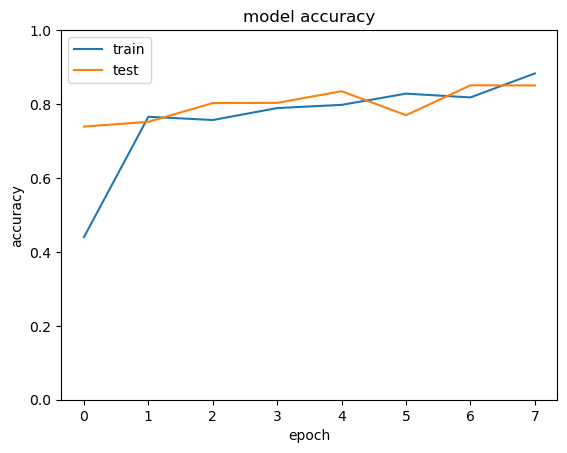

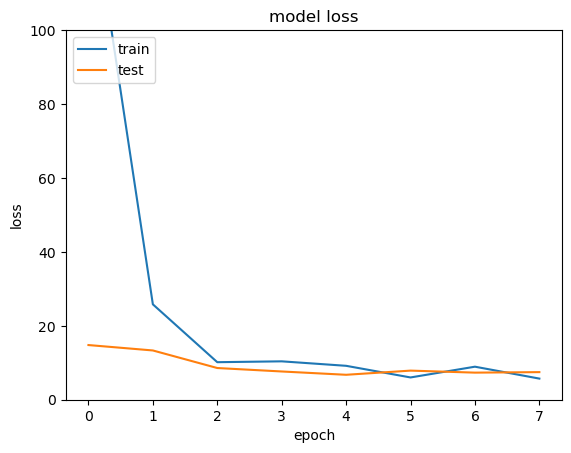

In [13]:
#Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.ylim(0,1.00)
plt.show()

#Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.ylim(0,100)
plt.show()

## 7. Predictions on the held-out test set

In [14]:
Y_pred = model.predict(ts_gen, steps=int(np.ceil(ts_gen.n/Batch_size)))
Y_pred = np.argmax(Y_pred, axis=1)
Y_ts = ts_gen.classes

37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 624ms/step


/var/folders/4z/pydy4wk10_nfr03l78lbv80r0000gn/T/ipykernel_20724/3474122702.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([training_acc, test_acc], labels=['Train Accuracy', 'Test Accuracy'])


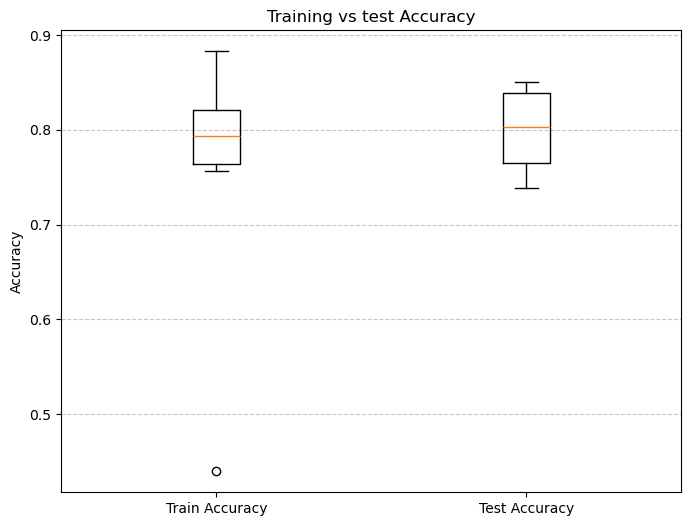

In [15]:
training_acc = history.history['accuracy']
test_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 6))

plt.boxplot([training_acc, test_acc], labels=['Train Accuracy', 'Test Accuracy'])

plt.title('Training vs test Accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [16]:
np.mean(training_acc)

0.7597501575946808

In [17]:
np.mean(test_acc)

0.8002797737717628

## 8. Confusion matrix and error analysis

The confusion matrix shows *where* the model fails, which is far more informative than the
headline accuracy number.

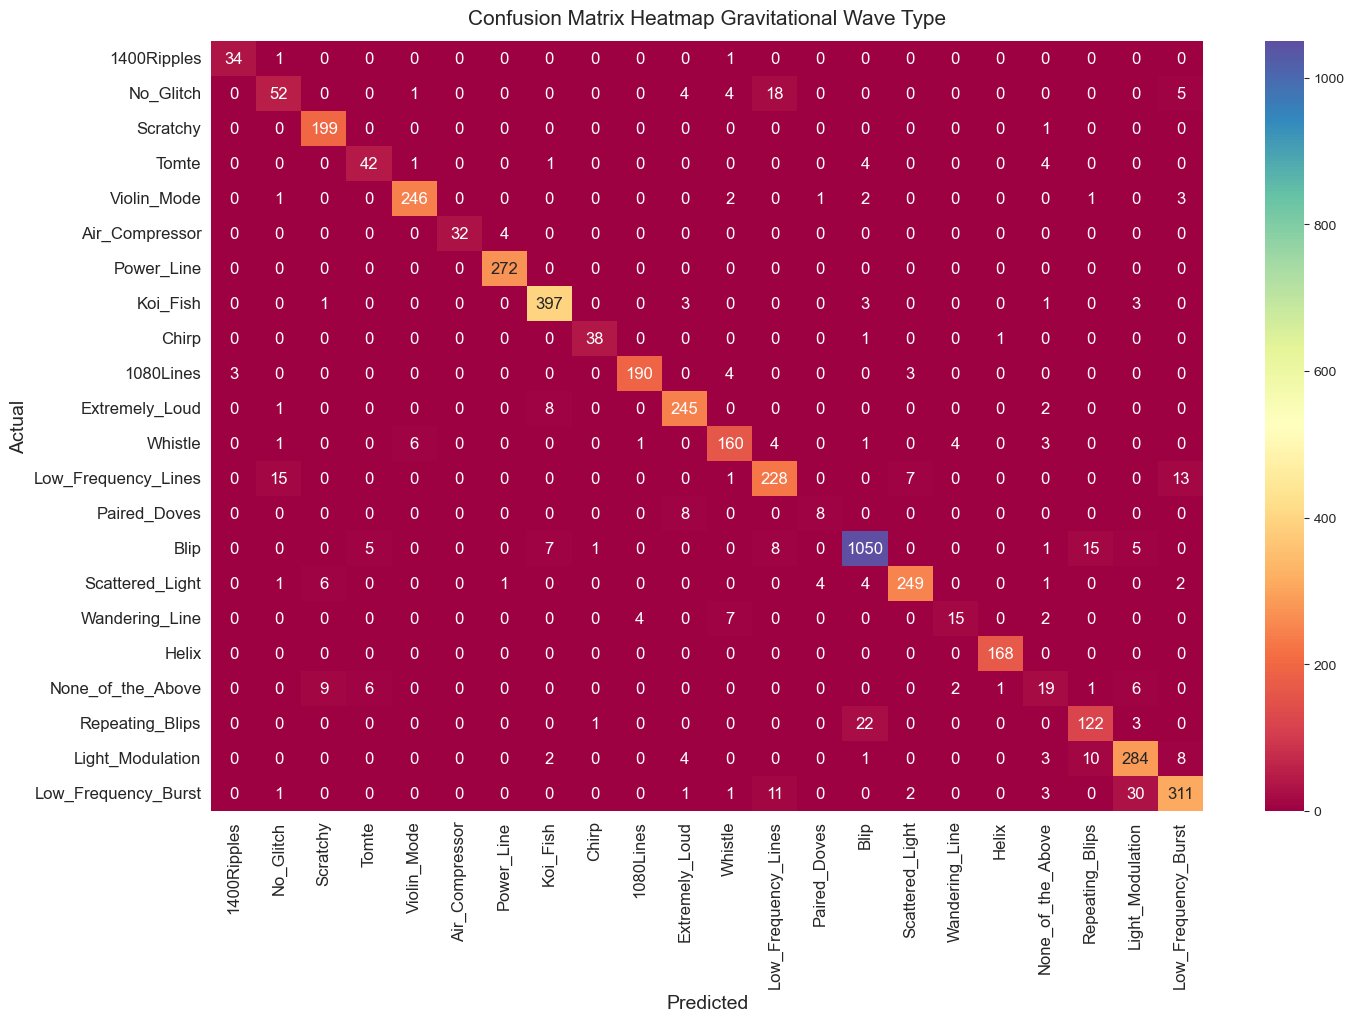

-Accuracy achieved: 92.39%
-Accuracy by model: 98.44%
-Accuracy by validation: 92.25%


In [23]:
conf_mat = confusion_matrix(Y_ts,Y_pred)
sns.set_style(style='white')
plt.figure(figsize=(16,10))
heatmap = sns.heatmap(conf_mat,vmin=np.min(conf_mat.all()), vmax=np.max(conf_mat), annot=True,fmt='d', annot_kws={"fontsize":12},cmap='Spectral')
heatmap.set_title('Confusion Matrix Heatmap Gravitational Wave Type', fontdict={'fontsize':15}, pad=12)
heatmap.set_xlabel('Predicted',fontdict={'fontsize':14})
heatmap.set_ylabel('Actual',fontdict={'fontsize':14})
heatmap.set_xticklabels(class_names, fontdict={'fontsize':12,'rotation': 90})
heatmap.set_yticklabels(class_names, fontdict={'fontsize':12,'rotation': 0})
plt.show()

print('-Accuracy achieved: {:.2f}%\n-Accuracy by model: {:.2f}%\n-Accuracy by validation: {:.2f}%'.
      format(accuracy_score(Y_ts,Y_pred)*100,(history.history['accuracy'][-1])*100,(history.history['val_accuracy'][-1])*100))

## 9. Results

| Metric | Value |
|---|---|
| **Test accuracy (held out)** | **92.39%** |
| Final validation accuracy | 92.25% |
| Final training accuracy | 98.44% |

See the README for a discussion of the remaining errors and what I would change next.